In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

In [2]:
IMAGE_SIZE = 256
BATCH_SIZE =32
CHANNELS = 3
EPOCHS = 50

In [3]:
#LOAD DATASET

In [4]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage" ,
    shuffle = True,
    image_size = (IMAGE_SIZE,IMAGE_SIZE),
    batch_size = BATCH_SIZE
)

Found 5702 files belonging to 3 classes.


In [5]:
class_names = dataset.class_names
class_names


['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [6]:
len(dataset)

179

In [7]:
 179*32  #no of batches x batch size= total dataset images

5728

In [8]:
for image_batch, label_batch in dataset.take(1):
    print(image_batch[0].numpy())

[[[144. 138. 148.]
  [155. 149. 159.]
  [141. 135. 145.]
  ...
  [156. 149. 156.]
  [146. 139. 146.]
  [161. 154. 161.]]

 [[163. 157. 167.]
  [170. 164. 174.]
  [157. 151. 161.]
  ...
  [157. 150. 157.]
  [156. 149. 156.]
  [165. 158. 165.]]

 [[173. 167. 177.]
  [178. 172. 182.]
  [169. 163. 173.]
  ...
  [167. 160. 167.]
  [158. 151. 158.]
  [142. 135. 142.]]

 ...

 [[194. 189. 195.]
  [192. 187. 193.]
  [192. 187. 193.]
  ...
  [197. 192. 198.]
  [196. 191. 197.]
  [197. 192. 198.]]

 [[198. 193. 199.]
  [196. 191. 197.]
  [194. 189. 195.]
  ...
  [196. 191. 197.]
  [194. 189. 195.]
  [195. 190. 196.]]

 [[202. 197. 203.]
  [201. 196. 202.]
  [197. 192. 198.]
  ...
  [196. 191. 197.]
  [193. 188. 194.]
  [194. 189. 195.]]]


In [9]:
for image_batch, label_batch in dataset.take(1):
    print(image_batch[0].shape)

(256, 256, 3)


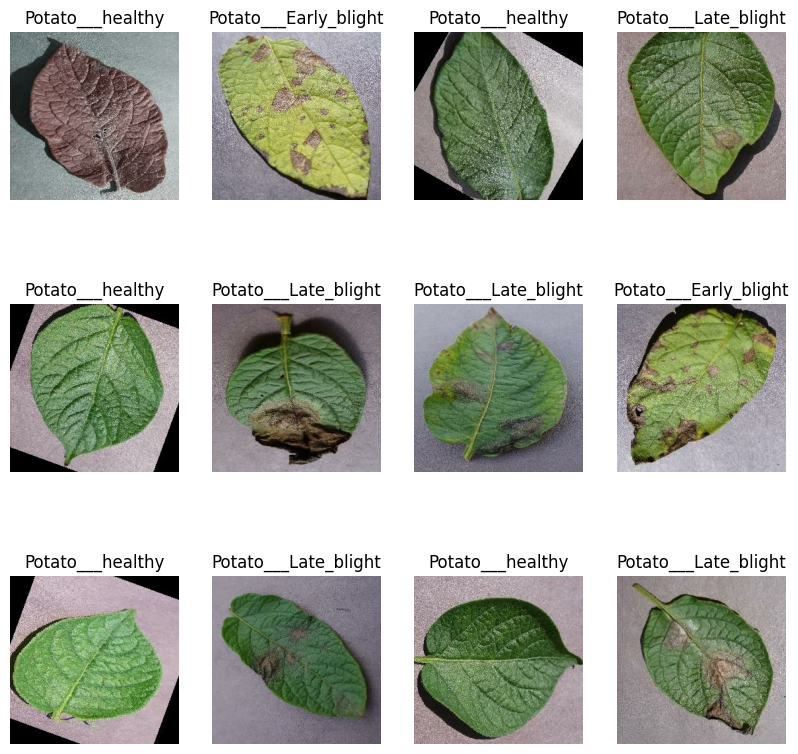

In [10]:
#diplay single image from batch
plt.figure(figsize = (10,10))
for image_batch, label_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3,4, i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8")) #converting image to integer
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

In [11]:
len(dataset)

179

In [12]:
#80% ==> Training
#20% ==> 10% validation, 10% test

In [13]:
train_size = 0.8
len(dataset)*train_size

143.20000000000002

In [14]:
train_ds=dataset.take(143)
len(train_ds)

143

In [15]:
test_ds = dataset.skip(143) # test dataset size
len(test_ds)

36

In [16]:
val_size=0.1    # 10% dataset for validation
len(dataset)*val_size

17.900000000000002

In [17]:
val_ds = test_ds.take(17)
len(val_ds)

17

In [18]:
test_ds = test_ds.skip(17) #  10% dataset for actual testing
len(test_ds)

19

In [19]:
#Function for taint_test_split
def get_dataset_partitions_tf(ds, train_split = 0.8, val_split = 0.1, test_split = 0.1, shuffle =True, shuffle_size=10000):
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    train_size = int(train_split*ds_size)
    val_size = int (val_split*ds_size)
    
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
                     
    return train_ds, val_ds, test_ds
    

In [20]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [21]:
len(train_ds)

143

In [22]:
len(test_ds)

19

In [23]:
len(val_ds)

17

In [24]:
#optimize dataset to run fastly
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
tets_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [25]:
#Pre-processing
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0/255)
])
    

Data Augumentation

In [26]:
data_augumentation = tf.keras.Sequential([
    #layers.experimental.preprocessing.RandomFlip("horizantal_and_vertical"),
    #layers.experimental.preprocessing.RandomRotation(0.2)
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])
    

In [27]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3
model = models.Sequential([
    resize_and_rescale,
    data_augumentation,
    layers.Conv2D(32, (3,3), activation='relu', input_shape = input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size= (3,3), activation= 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size= (3,3), activation= 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation= 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation= 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation= 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])    
model.build(input_shape=input_shape)

F:\SNS\PhD-Project\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (32, 254, 254, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (32, 127, 127, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (32, 125, 125, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (32, 62, 62, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (32, 60, 60, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (32, 30, 30, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (32, 28, 28, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (32, 14, 14, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (32, 12, 12, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (32, 6, 6, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (32, 4, 4, 64)              │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (32, 2, 2, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (32, 256)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (32, 64)                    │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (32, 3)                     │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [30]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_data=val_ds,
)

Epoch 1/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 395s 2s/step - accuracy: 0.4849 - loss: 0.9612 - val_accuracy: 0.8364 - val_loss: 0.4142
Epoch 2/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 242s 2s/step - accuracy: 0.8232 - loss: 0.4361 - val_accuracy: 0.8676 - val_loss: 0.3284
Epoch 3/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 127s 885ms/step - accuracy: 0.9088 - loss: 0.2358 - val_accuracy: 0.9173 - val_loss: 0.2250
Epoch 4/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 125s 872ms/step - accuracy: 0.9173 - loss: 0.2127 - val_accuracy: 0.8143 - val_loss: 0.6634
Epoch 5/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 123s 864ms/step - accuracy: 0.9518 - loss: 0.1272 - val_accuracy: 0.8897 - val_loss: 0.3003
Epoch 6/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 123s 863ms/step - accuracy: 0.9660 - loss: 0.0844 - val_accuracy: 0.8713 - val_loss: 0.3803
Epoch 7/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 128s 892ms/step - accuracy: 0.9728 - loss: 0.0779 - val_accuracy: 0.9375 - val_loss: 0.1804
Epoch 8/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 123s 858ms/step - accuracy: 0.9639 - loss:

In [31]:
scores=model.evaluate(test_ds)

19/19 ━━━━━━━━━━━━━━━━━━━━ 286s 497ms/step - accuracy: 0.9911 - loss: 0.0131


In [32]:
history

In [33]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 143}

In [35]:
history.history['accuracy']

[0.6274725198745728,
 0.8419780135154724,
 0.917362630367279,
 0.9316483736038208,
 0.9523077011108398,
 0.9652747511863708,
 0.9764835238456726,
 0.9701098799705505,
 0.9791208505630493,
 0.9868131875991821,
 0.9846153855323792,
 0.9879120588302612,
 0.9795604348182678,
 0.9881318807601929,
 0.9920879006385803,
 0.9881318807601929,
 0.9905494451522827,
 0.9894505739212036,
 0.9931868314743042,
 0.9907692074775696,
 0.9859340786933899,
 0.9934065937995911,
 0.9901098608970642,
 0.9934065937995911,
 0.9995604157447815,
 0.9967032670974731,
 0.9920879006385803,
 0.9835164546966553,
 0.9949450492858887,
 0.9995604157447815,
 0.9951648116111755,
 0.9938461780548096,
 0.9949450492858887,
 0.995604395866394,
 0.9830769300460815,
 0.9931868314743042,
 0.9879120588302612,
 0.9920879006385803,
 0.9960439801216125,
 0.9947252869606018,
 0.9984615445137024,
 0.9989010691642761,
 0.9991208910942078,
 0.9949450492858887,
 0.9953846335411072,
 0.9903296828269958,
 0.9973626136779785,
 0.991648375988

In [36]:
history.history['accuracy']

[0.6274725198745728,
 0.8419780135154724,
 0.917362630367279,
 0.9316483736038208,
 0.9523077011108398,
 0.9652747511863708,
 0.9764835238456726,
 0.9701098799705505,
 0.9791208505630493,
 0.9868131875991821,
 0.9846153855323792,
 0.9879120588302612,
 0.9795604348182678,
 0.9881318807601929,
 0.9920879006385803,
 0.9881318807601929,
 0.9905494451522827,
 0.9894505739212036,
 0.9931868314743042,
 0.9907692074775696,
 0.9859340786933899,
 0.9934065937995911,
 0.9901098608970642,
 0.9934065937995911,
 0.9995604157447815,
 0.9967032670974731,
 0.9920879006385803,
 0.9835164546966553,
 0.9949450492858887,
 0.9995604157447815,
 0.9951648116111755,
 0.9938461780548096,
 0.9949450492858887,
 0.995604395866394,
 0.9830769300460815,
 0.9931868314743042,
 0.9879120588302612,
 0.9920879006385803,
 0.9960439801216125,
 0.9947252869606018,
 0.9984615445137024,
 0.9989010691642761,
 0.9991208910942078,
 0.9949450492858887,
 0.9953846335411072,
 0.9903296828269958,
 0.9973626136779785,
 0.991648375988

In [37]:
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

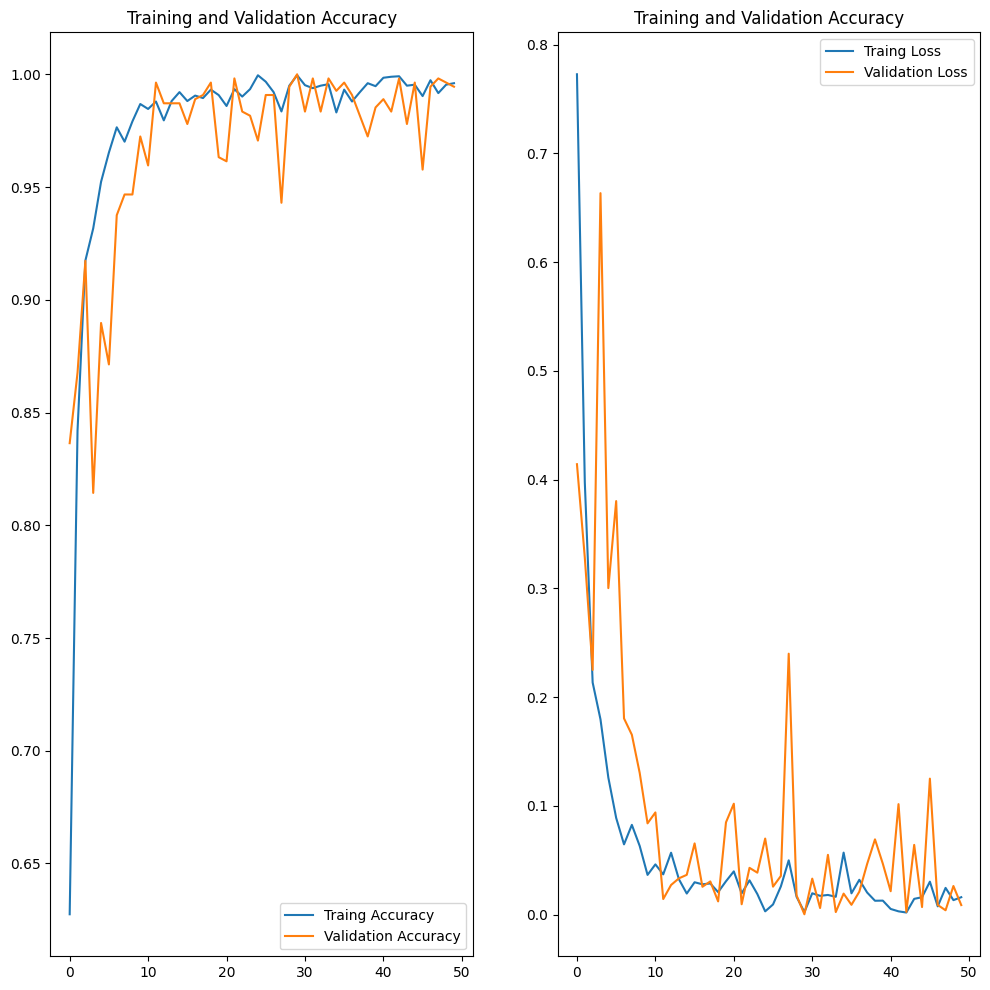

In [43]:
plt.figure(figsize=(12,12))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), acc, label="Traing Accuracy")
plt.plot(range(EPOCHS), val_acc, label="Validation Accuracy")
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(range(EPOCHS), loss, label="Traing Loss")
plt.plot(range(EPOCHS), val_loss, label="Validation Loss")
plt.legend(loc='upper right')
plt.title('Training and Validation Accuracy')

plt.show()



first image to predict
actual labe: Potato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
predicted labe: Potato___Late_blight


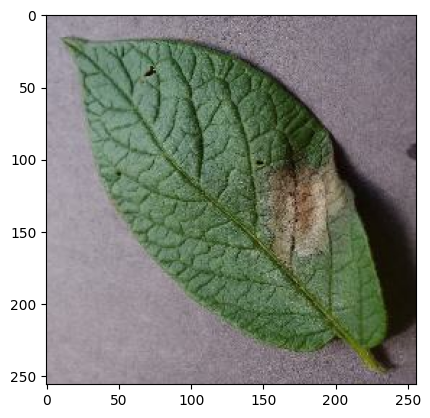

In [39]:
import numpy as np
for images_batch, label_batch in test_ds.take(1):

    first_image = images_batch[0].numpy().astype('uint8')
    first_label = label_batch[0].numpy()

    print("first image to predict")
    plt.imshow(first_image)
    print("actual labe:", class_names[first_label])

    batch_prediction = model.predict(images_batch)
    print("predicted labe:", class_names[np.argmax(batch_prediction[0])])

    

In [44]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    prediction = model.predict(img_array)

    prediction_class = class_names[np.argmax(batch_prediction[0])]
    confidence = round(100*(np.max(prediction[0])), 2)
    return prediction_class, confidence
    

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


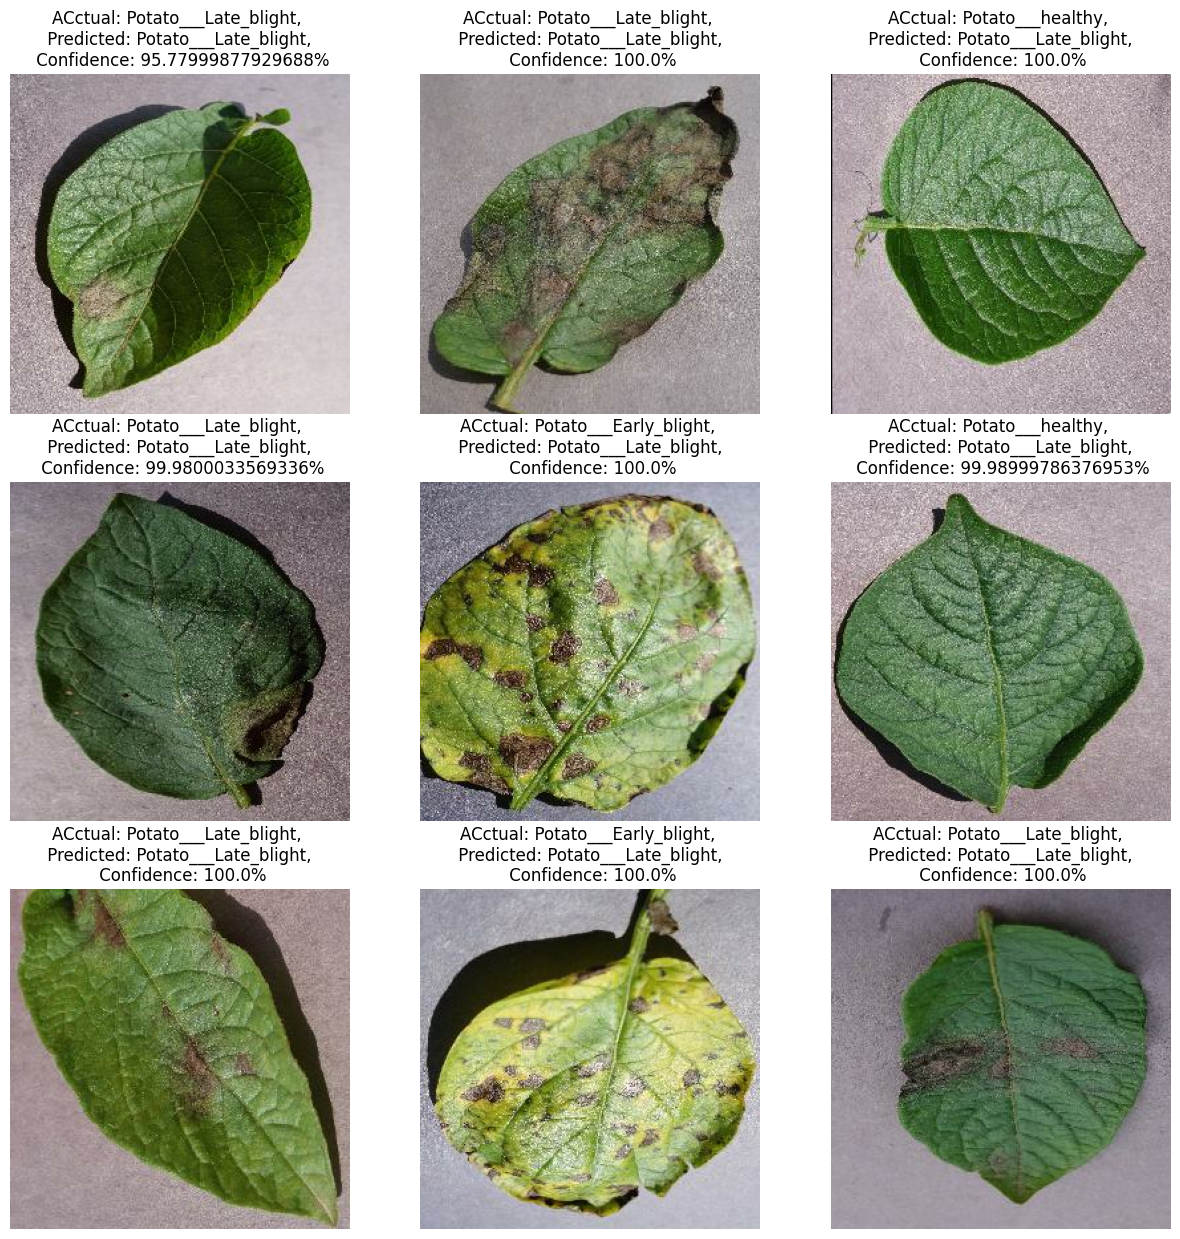

In [45]:
plt.figure(figsize=(15,15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(f"ACctual: {actual_class}, \n Predicted: {predicted_class}, \n Confidence: {confidence}%")

        plt.axis("off")

In [46]:
model_version=2
model.export(f"../models/{model_version}")

INFO:tensorflow:Assets written to: ../models/2\assets


INFO:tensorflow:Assets written to: ../models/2\assets


Saved artifact at '../models/2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1424978376272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1424978374352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1425167441296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1425167442640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1425167441104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1425167441488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1425167443792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1425167443024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1425167442832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1425167444752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1425167444560: TensorSpec(shape=(), dty

In [64]:
import pandas as pd
import csv
df1 = pd.DataFrame(data={"Accuracy": acc, "Val_Accuracy": val_acc, "Loss": loss, "Val_loss": val_loss}) 
df1.to_csv("./Potato_Result.csv", sep=',',index=False)